Dataset is located within shared google drive. Sign in to access.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
print(os.path.exists('/content/drive/MyDrive/train'))
print(os.listdir('/content/drive/MyDrive/train'))

True
['Glioblastoma', 'Metastatic', 'Schwannoma', 'glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


Using device: cuda
Total images:  7897
Classes found: ['Glioblastoma', 'Metastatic', 'Schwannoma', 'glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
Class mapping: {'Glioblastoma': 0, 'Metastatic': 1, 'Schwannoma': 2, 'glioma_tumor': 3, 'meningioma_tumor': 4, 'no_tumor': 5, 'pituitary_tumor': 6}
Train samples: 6317  Val samples: 790  Test samples: 790
Data Loaded!


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Model Initialised!
Trainable parameters: 2,076 out of 11,182,179
Starting Training


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch 1/4 | Loss: 2.1488 | Macro-F1: 0.2479
Epoch 2/4 | Loss: 1.9232 | Macro-F1: 0.2770
Epoch 3/4 | Loss: 1.7962 | Macro-F1: 0.3190
Epoch 4/4 | Loss: 1.6385 | Macro-F1: 0.3933


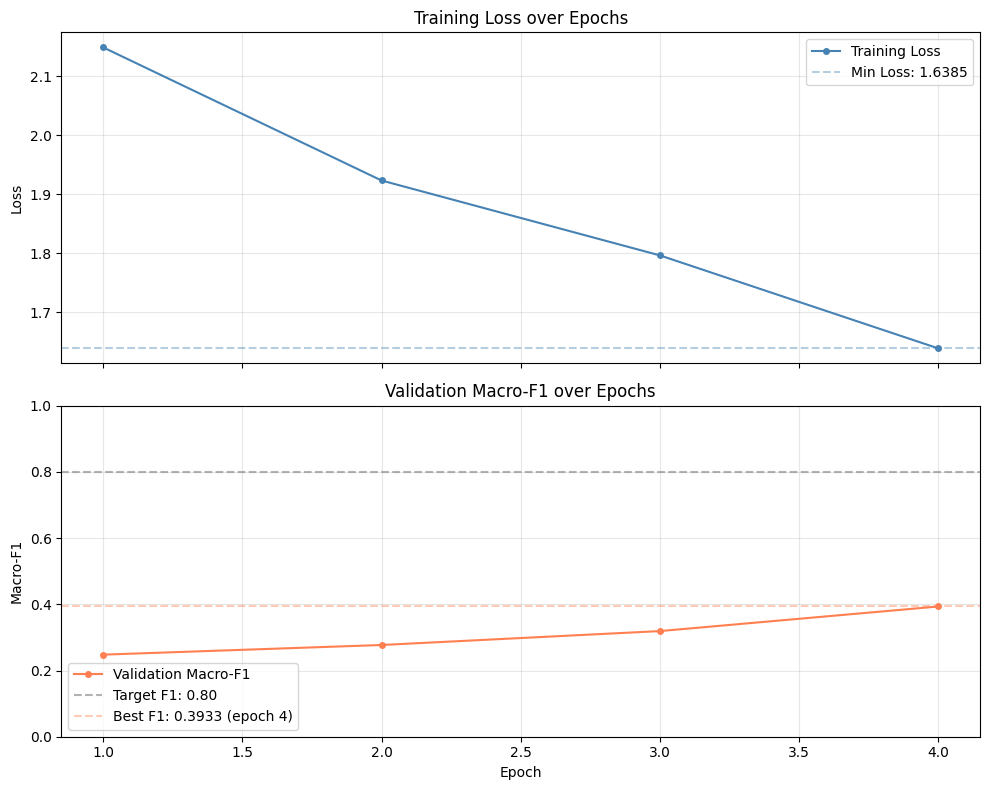

Graph saved to Google Drive
Starting Testing!
Duration of test computation:  0.7161710262298584  sec


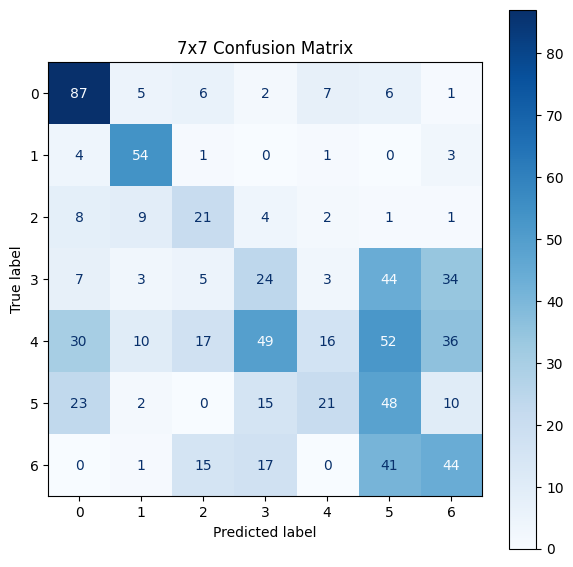

Macro F1: 0.39232299997580217
Correct indices: [32, 64, 612]
Incorrect indices: [306, 338, 233]


|| -------------------- Correctly Identified Images: -------------------- ||


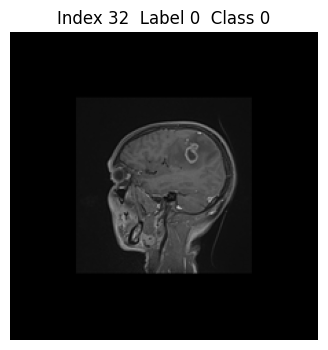

Correct class: Glioblastoma
Predicted class: Glioblastoma


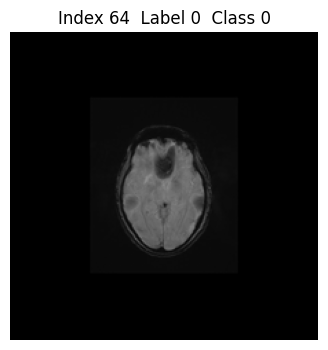

Correct class: Glioblastoma
Predicted class: Glioblastoma


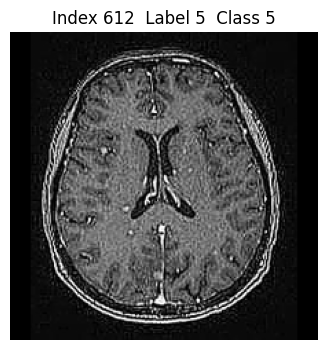

Correct class: no_tumor
Predicted class: no_tumor


|| -------------------- Incorrectly Identified Images: -------------------- ||


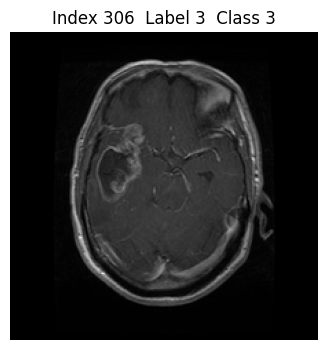

Correct class: glioma_tumor
Predicted class: no_tumor


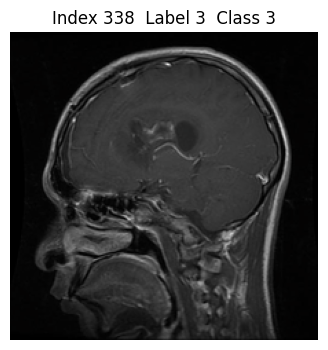

Correct class: glioma_tumor
Predicted class: pituitary_tumor


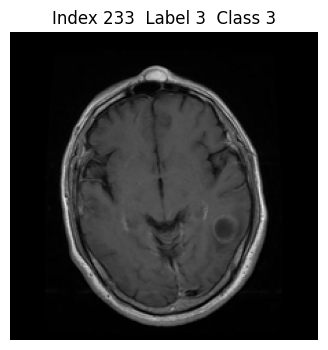

Correct class: glioma_tumor
Predicted class: no_tumor


In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.init as init
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Subset
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import time
import math
from collections import Counter

torch.manual_seed(73)
np.random.seed(73)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# -------------------- load dataset -------------------- #
# location of the drive in my personal google drive -Bradly
# the way i set this up, is after Ethan shared the drive with me
# right click the folder, organize, add shortcut, then add it onto
# 'myDrive'


DATASET_PATH = '/content/drive/MyDrive/train'

train_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

full_dataset = ImageFolder(root=DATASET_PATH, transform=train_transforms)
N = len(full_dataset)

print(f"Total images:  {len(full_dataset)}")
print(f"Classes found: {full_dataset.classes}")
print(f"Class mapping: {full_dataset.class_to_idx}")

train_idx = [i for i in range(N) if i % 10 not in (0, 1)]
val_idx = list(range(1, N, 10))
test_idx = list(range(0, N, 10))

train_len = len(train_idx)
val_len = len(val_idx)
test_len = len(test_idx)
print(f"Train samples: {train_len}  Val samples: {val_len}  Test samples: {test_len}")

train_ds = Subset(full_dataset, train_idx)
val_ds = Subset(full_dataset, val_idx)
test_ds = Subset(full_dataset, test_idx)

batch_size = 32
num_workers = 4
train_load = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True, persistent_workers=True)
val_load = DataLoader(val_ds,  batch_size=val_len, shuffle=False, num_workers=max(1, num_workers//2), pin_memory=True, persistent_workers=True)
test_load = DataLoader(test_ds,  batch_size=test_len, shuffle=False, num_workers=max(1, num_workers//2), pin_memory=True, persistent_workers=True)

print("Data Loaded!")

# -------------------- set up resnet18 neural network -------------------- #
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1) # sets up resnet18 pretrained model

model.fc = nn.Linear(model.fc.in_features, 7) # creates output layer (7 outputs; one for each classification)

init.kaiming_normal_(model.fc.weight, mode='fan_in', nonlinearity='relu')
init.zeros_(model.fc.bias) # initialises output layer weights (randoms for ReLu) and biases (zeros)

#model = model.to(device) # move the model to the GPU

print("Model Initialised!")

# -------------------- fine tune model using LoRA rank-4 -------------------- # (no need to set up until after midterm report)

class LoRALayer(nn.Module):
    def __init__(self, original_layer, rank=4):
        super().__init__()
        self.original_layer = original_layer
        in_features  = original_layer.in_features
        out_features = original_layer.out_features

        # freeze the original layer
        for param in self.original_layer.parameters():
            param.requires_grad = False

        # LoRA matrices A and B
        self.lora_A = nn.Parameter(torch.randn(in_features, rank) * 0.01)
        self.lora_B = nn.Parameter(torch.zeros(rank, out_features))
        self.rank = rank

    def forward(self, x):
        return self.original_layer(x) + x @ self.lora_A @ self.lora_B

# freeze all backbone layers
for param in model.parameters():
    param.requires_grad = False

# wrap the final fc layer with LoRA rank-4
model.fc = LoRALayer(model.fc, rank=4)
model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f'Trainable parameters: {trainable:,} out of {total:,}')


# -------------------- Training loop -------------------- #

labels_list = [label for _, label in full_dataset.samples]
class_counts = Counter(labels_list)
total_samples = sum(class_counts.values())
weights = [total_samples / class_counts[i] for i in range(7)]
weights = torch.tensor(weights, dtype=torch.float).to(device)

optimizer = optim.Adam(model.parameters(), lr=0.0002)
criterion = nn.CrossEntropyLoss(weight=weights)

NUM_EPOCHS = 4
best_f1 = 0

print("Starting Training")

train_losses = []
val_f1s = []

for epoch in range(NUM_EPOCHS):
    # train
    model.train()
    running_loss = 0.0
    for i, (images, labels) in enumerate(train_load):
        #if (epoch == 0) and (i % 10 == 0): print("iteration: "+str(i))
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # validate
    #print("Validating...")
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in val_load:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    avg_loss = running_loss / len(train_load) # Calculate average loss per batch
    train_losses.append(avg_loss)
    val_f1s.append(macro_f1)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {avg_loss:.4f} | Macro-F1: {macro_f1:.4f}")

    if macro_f1 > best_f1:
        best_f1 = macro_f1
        torch.save(model.state_dict(), '/content/drive/MyDrive/best_model.pth')
        #print(f"  New best model saved! F1: {best_f1:.4f}")


# -------------------- training curves -------------------- #

epochs = list(range(1, NUM_EPOCHS+1))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# loss plot
ax1.plot(epochs, train_losses, color='steelblue', marker='o', markersize=4, linewidth=1.5, label='Training Loss')
ax1.axhline(y=min(train_losses), color='steelblue', linestyle='--', alpha=0.4, label=f'Min Loss: {min(train_losses):.4f}')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss over Epochs')
ax1.legend()
ax1.grid(True, alpha=0.3)

# macro-f1 plot
ax2.plot(epochs, val_f1s, color='coral', marker='o', markersize=4, linewidth=1.5, label='Validation Macro-F1')
ax2.axhline(y=0.80, color='gray', linestyle='--', alpha=0.6, label='Target F1: 0.80')
ax2.axhline(y=max(val_f1s), color='coral', linestyle='--', alpha=0.4, label=f'Best F1: {max(val_f1s):.4f} (epoch {val_f1s.index(max(val_f1s))+1})')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Macro-F1')
ax2.set_title('Validation Macro-F1 over Epochs')
ax2.set_ylim(0.0, 1.0)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/training_curves_20epochs.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graph saved to Google Drive")


# -------------------- test with Macro-F1 value and graphs -------------------- #

model.eval() # warm up GPU if available; this code generated with prompt: "For a resnet18 model, write a short program to warm up the GPU"
with torch.no_grad():
    # warm-up iterations
    if device.type == 'cuda':
        for _ in range(3):
            _ = model(torch.randn(8, 3, 224, 224, device=device))


test_set = iter(test_load)
cur_batch, targets = next(test_set) # load the test set for testing
cur_batch = cur_batch.to(device, non_blocking=True)

t = time.time()
print("Starting Testing!")

with torch.no_grad(): # run the test batch through the model
    logits = model(cur_batch)
torch.cuda.synchronize() if device.type == 'cuda' else None

dt = time.time() - t
print("Duration of test computation: ", dt, " sec")

preds = torch.argmax(logits, dim=1) # find the index of the largest output for each image

preds_cpu = preds.cpu().numpy()
targets_cpu = targets.cpu().numpy()

labels = list(range(7))
cm = confusion_matrix(targets_cpu, preds_cpu, labels=labels) # create confusion matrix for viewing

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels) # display confusion matrix
fig, ax = plt.subplots(figsize=(7,7))
disp.plot(ax=ax, cmap=plt.cm.Blues, values_format='d')
plt.title("7x7 Confusion Matrix")
plt.show()

macro_f1 = f1_score(targets_cpu, preds_cpu, labels=list(range(7)), average='macro', zero_division=0) # calculate the Macro-F1 score of the test set and display it
print("Macro F1:", macro_f1)

correct_idx = [-1,-1,-1]
incorrect_idx = [-1,-1,-1]
i=0
for n in range(3):
  while correct_idx[n] == -1:
    i = (i+137)%test_len
    if preds_cpu[i] == targets_cpu[i]:
      correct_idx[n] = i
    if i==0: break
  while incorrect_idx[n] == -1:
    i = (i+137)%test_len
    if preds_cpu[i] != targets_cpu[i]:
      incorrect_idx[n] = i
    if i==0: break
print("Correct indices: "+str(correct_idx))
print("Incorrect indices: "+str(incorrect_idx))

import matplotlib.pyplot as plt # the following two functions were generated with the prompt: "How do I view the 3 correct images and 3 incorrect images with the predicted class and correct class in the following code?"
import numpy as np
import torch

def unnormalize_tensor(img_tensor, mean, std):
    img = img_tensor.clone().cpu()
    for t, m, s in zip(img, mean, std):
        t.mul_(s).add_(m)
    img = img.numpy().transpose(1, 2, 0)
    img = np.clip(img, 0, 1)
    return img

def show_image_at_index(dataset, idx, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
    """
    Display the image at index idx from an ImageFolder dataset.
    - dataset: torchvision.datasets.ImageFolder
    - idx: integer index
    - mean/std: used only if the image is a normalized tensor
    """
    img, label = dataset[idx]  # dataset returns (image, label)
    class_name = dataset.classes[label] if hasattr(dataset, 'classes') else str(label)

    # If transform returned a tensor (C,H,W)
    if isinstance(img, torch.Tensor):
        # If values are in [0,1] already and not normalized, this will still work
        try:
            img_np = unnormalize_tensor(img, mean, std)
        except Exception:
            # fallback: assume tensor already in [0,1]
            img_np = img.clone().cpu().numpy().transpose(1,2,0)
            img_np = np.clip(img_np, 0, 1)
    else:
        # PIL Image or numpy array
        try:
            img_np = np.array(img) / 255.0
        except Exception:
            raise RuntimeError("Unsupported image type: {}".format(type(img)))

    plt.figure(figsize=(4,4))
    plt.imshow(img_np)
    plt.title(f"Index {idx}")
    plt.axis('off')
    plt.show()

print("")
print("")
print("|| -------------------- Correctly Identified Images: -------------------- ||")
for n in range(3):
  show_image_at_index(test_ds, correct_idx[n])
  print("Correct class: "+str(full_dataset.classes[targets_cpu[correct_idx[n]]]))
  print("Predicted class: "+str(full_dataset.classes[preds_cpu[correct_idx[n]]]))

print("")
print("")
print("|| -------------------- Incorrectly Identified Images: -------------------- ||")
for n in range(3):
  show_image_at_index(test_ds, incorrect_idx[n])
  print("Correct class: "+str(full_dataset.classes[targets_cpu[incorrect_idx[n]]]))
  print("Predicted class: "+str(full_dataset.classes[preds_cpu[incorrect_idx[n]]]))
